<a href="https://colab.research.google.com/github/teerapat1122/teerapat_67080502233/blob/main/Lab03_SpeechRecognition_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🤖 DSP Lab 03: The Machine That Listens (Speech Recognition)

ใน Lab 02 เราได้เรียนรู้การใช้ **FFT** และ **Spectrogram** เพื่อแปลงเสียงให้กลายเป็นภาพ 2 มิติกันไปแล้ว
ใน Lab นี้ เราจะนำ "ภาพ Spectrogram" เหล่านั้นมาป้อนให้ **โครงข่ายประสาทเทียม (Artificial Neural Network - ANN)** เพื่อสอนให้คอมพิวเตอร์ "ฟัง" และ "เข้าใจ" เสียงพูดของมนุษย์!

---

## 🛠️ Step 0: เตรียมเครื่องมือ (Setup)
รัน Cell ด้านล่างเพื่อนำเข้า Library ที่จำเป็น เราจะใช้ `librosa` สำหรับจัดการเสียง และ `TensorFlow/Keras` สำหรับสร้าง AI

In [ ]:
import os
import time
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import tensorflow as tf
from tensorflow.keras import layers, models
from IPython.display import Audio, display, HTML, clear_output
from google.colab.output import eval_js
from base64 import b64decode

print("✅ เครื่องมือพร้อมสำหรับการสร้าง AI!")

---
## 📥 Mission 1: Data Harvesting (รวบรวมข้อมูลเสียง)
AI จะฉลาดได้ต้องมีข้อมูลให้เรียนรู้ เราจะดาวน์โหลดชุดข้อมูล **Mini Speech Commands** ซึ่งประกอบด้วยไฟล์เสียงพูดสั้นๆ (1 วินาที)

In [15]:
# 1. แตกไฟล์ zip ที่อัปโหลดขึ้นมา (thai_Mix_dataset.zip)
!unzip -q -o thai_Mix_dataset.zip -d my_data/

# ตรวจสอบว่ามีอะไรอยู่ในโฟลเดอร์ my_data บ้าง
print("Contents of my_data/ after unzip:")
!ls -F my_data/

# 2. กำหนด path ไปยังโฟลเดอร์ที่แตกออกมา
# (ปกติ unzip จะสร้างโฟลเดอร์ชื่อเดียวกับไฟล์ zip หรือตามโครงสร้างข้างใน)
# หากไฟล์ zip แตกออกมาตรงๆ ใน my_data/ โดยไม่มีโฟลเดอร์ thai_Mix_dataset ซ้ำซ้อน ให้ใช้ data_dir = pathlib.Path('my_data')
data_dir = pathlib.Path('my_data') # ปรับแก้ให้ชี้ไปที่ my_data โดยตรง

# 3. อ่านรายชื่อคำศัพท์จากโฟลเดอร์
commands = np.array(tf.io.gfile.listdir(str(data_dir)))
# กรองเอาเฉพาะโฟลเดอร์คำสั่งเสียง
commands = np.array([c for c in commands if (data_dir / c).is_dir()])

print("คำศัพท์ที่ AI ของเราจะต้องเรียนรู้ (Classes):", commands)
print("จำนวนคำศัพท์ทั้งหมด =", len(commands), "คำ")

# 4. ลองฟังเสียงตัวอย่างจากคำแรกในลิสต์
if len(commands) > 0:
    test_word = commands[0]
    # ค้นหาไฟล์ .wav แรกที่เจอในโฟลเดอร์นั้น
    sample_files = list((data_dir / test_word).glob('*.wav'))
    if sample_files:
        sample_audio_path = str(sample_files[0])
        print(f"\nลองฟังเสียงตัวอย่างคำว่า: '{test_word}'")
        display(Audio(sample_audio_path))
    else:
        print(f"\nไม่พบไฟล์ .wav ในโฟลเดอร์ '{test_word}'")

Contents of my_data/ after unzip:
ก้าว/  มา/  ยัง/	วิ่ง/
คำศัพท์ที่ AI ของเราจะต้องเรียนรู้ (Classes): ['ยัง' 'วิ่ง' 'มา' 'ก้าว']
จำนวนคำศัพท์ทั้งหมด = 4 คำ

ลองฟังเสียงตัวอย่างคำว่า: 'ยัง'


---
## 🌈 Mission 2: Feature Extraction (The Mel Scale)
AI แบบ CNN เก่งเรื่องการดูรูปภาพ เราจึงต้องแปลงเสียงให้เป็นภาพ **Mel-Spectrogram**

**💡 ทบทวนความรู้จาก Slide:** หูมนุษย์รับรู้ความถี่แบบไม่เป็นเส้นตรง เรามักจะบีบความถี่เป็นแบนด์ (Mel bands) จำนวน 64 แบนด์ และเสียงพูดปกติจะมีความถี่ไม่เกิน 8,000 Hz

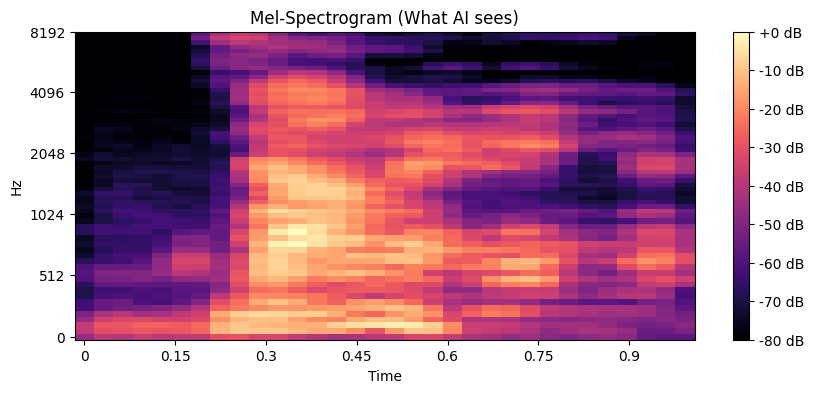

In [17]:
y, sr = librosa.load(sample_audio_path, sr=16000)

# ---------------------------------------------------------
# 🎯 ภารกิจที่ 1: เติมพารามิเตอร์ให้ตรงกับทฤษฎีการได้ยินของมนุษย์
# ---------------------------------------------------------
S = librosa.feature.melspectrogram(y=y, sr=sr,
                                   n_mels=64,
                                   fmax=8000)

S_dB = librosa.power_to_db(S, ref=np.max)

plt.figure(figsize=(10, 4))
librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=sr, fmax=8000)
plt.colorbar(format='%+2.0f dB')
plt.title('Mel-Spectrogram (What AI sees)')
plt.show()

---
## 🧠 Mission 3: Building the Brain (สร้างสมอง AI)
เตรียมข้อมูลเสียงทั้งหมดและสร้างโมเดล **CNN**

**💡 ทบทวนความรู้จาก Slide:** Layer สุดท้ายของ Neural Network (Output Layer) จะต้องมีจำนวนเซลล์เท่ากับ "จำนวนคลาส" ที่เราต้องการแยกแยะ และใช้ฟังก์ชัน Softmax เพื่อแปลงเป็น % ความน่าจะเป็น

In [10]:
import pathlib
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

# Ensure data_dir is defined even if previous cells weren't run
data_dir = pathlib.Path('my_data')

train_ds, val_ds = tf.keras.utils.audio_dataset_from_directory(
    directory=data_dir, batch_size=64, validation_split=0.2,
    seed=0, output_sequence_length=16000, subset='both')

label_names = np.array(train_ds.class_names)
num_classes = len(label_names) # เก็บจำนวนคำศัพท์ไว้ในตัวแปรนี้

def get_spectrogram(audio, label):
  audio = tf.squeeze(audio, axis=-1)
  spectrogram = tf.signal.stft(audio, frame_length=255, frame_step=128)
  spectrogram = tf.abs(spectrogram)
  spectrogram = tf.expand_dims(spectrogram, -1)
  return spectrogram, label

train_spectrogram_ds = train_ds.map(map_func=get_spectrogram, num_parallel_calls=tf.data.AUTOTUNE)
val_spectrogram_ds = val_ds.map(map_func=get_spectrogram, num_parallel_calls=tf.data.AUTOTUNE)

for example_spectrograms, example_labels in train_spectrogram_ds.take(1):
  input_shape = example_spectrograms.shape[1:]

model = models.Sequential([
    layers.Input(shape=input_shape),
    layers.Resizing(32, 32),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    # ---------------------------------------------------------
    # 🎯 ภารกิจที่ 2: เติมจำนวน Node ของ Output Layer และ Activation Function
    # ---------------------------------------------------------
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Found 200 files belonging to 4 classes.
Using 160 files for training.
Using 40 files for validation.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 314,372 (1.20 MB)

 Trainable params: 314,372 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

---
## ⚔️ Mission 4: Training (กระบวนการฝึกฝน)
**💡 ทบทวนความรู้จาก Slide:** การฝึก AI ต้องทำซ้ำๆ เรียกว่า Epoch ยิ่ง Epoch เยอะ AI ยิ่งได้ทบทวนบทเรียน

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 287ms/step - accuracy: 0.2750 - loss: 1.4330 - val_accuracy: 0.8000 - val_loss: 0.9722
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - accuracy: 0.5688 - loss: 1.0240 - val_accuracy: 0.8250 - val_loss: 0.6999
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 153ms/step - accuracy: 0.7125 - loss: 0.8255 - val_accuracy: 0.8000 - val_loss: 0.5623
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 149ms/step - accuracy: 0.7375 - loss: 0.7170 - val_accuracy: 0.8500 - val_loss: 0.4428
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 173ms/step - accuracy: 0.7688 - loss: 0.5784 - val_accuracy: 0.9000 - val_loss: 0.3537
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - accuracy: 0.7937 - loss: 0.5064 - val_accuracy: 0.9250 - val_loss: 0.2763
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 138ms/step - accuracy: 0.8313 - loss: 0.4151 - val_accuracy: 0.9500 - val_loss: 0.2402
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.8062 - loss: 0.3928 - val_accuracy: 0.9250 - val_loss:

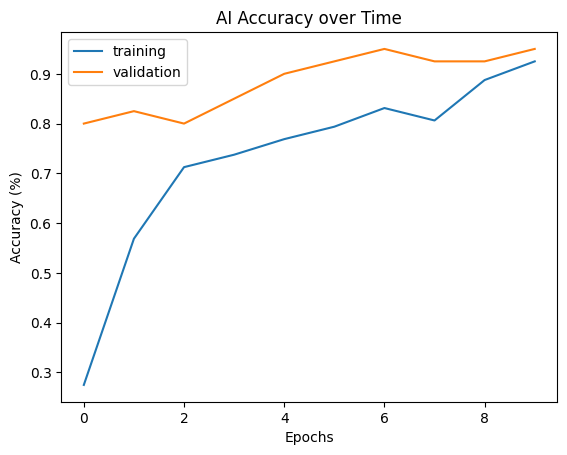

In [21]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# ---------------------------------------------------------
# 🎯 ภารกิจที่ 3: กำหนดรอบการฝึกฝน (ลองใส่สัก 10 รอบ)
# ---------------------------------------------------------
EPOCHS = 10

history = model.fit(
    train_spectrogram_ds,
    validation_data=val_spectrogram_ds,
    epochs=EPOCHS,
    callbacks=[tf.keras.callbacks.EarlyStopping(verbose=1, patience=2)],
)

metrics = history.history
plt.plot(history.epoch, metrics['accuracy'], metrics['val_accuracy'])
plt.legend(['training', 'validation'])
plt.title('AI Accuracy over Time')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.show()

---
## 🎙️ Mission 5: The Ultimate Test (ทดสอบเสียงของคุณเอง!)
เปิดไมโครโฟน แล้วพูดคำว่า `down, go, left, right, no, yes, stop, up` มา 1 คำ

**💡 ทบทวนความรู้จาก Slide (Data Consistency):** ไฟล์เสียงตอนทดสอบ ต้องมีขนาด Data Points เท่ากับตอนเทรนเป๊ะๆ ถ้าเราใช้เวลา 1 วินาที ที่ Sampling rate 16,000 Hz แปลว่าเราต้องการข้อมูลทั้งหมดกี่จุด?


🤖 AI มั่นใจว่าคุณพูดคำว่า: 👉 [ ก้าว ] 👈



/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3657 (\N{THAI CHARACTER MAI THO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw

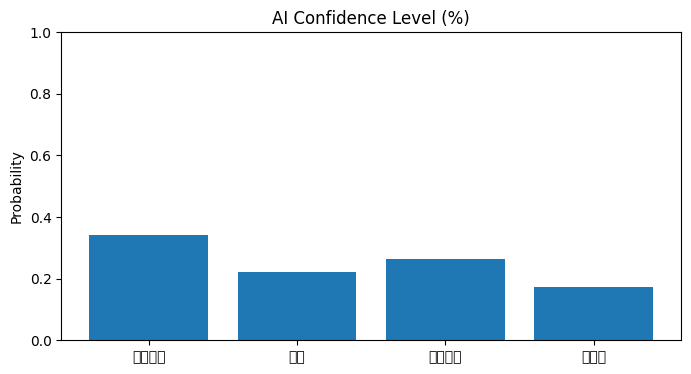

In [19]:
import time
import numpy as np
import tensorflow as tf
import librosa
import matplotlib.pyplot as plt

from IPython.display import HTML, display, clear_output
from google.colab.output import eval_js
from base64 import b64decode

# ติดตั้ง ffmpeg (สำคัญ)
!apt-get install -y ffmpeg

file_id = int(time.time())
webm_file = f'my_test_{file_id}.webm'
wav_file = f'my_test_{file_id}.wav'

AUDIO_HTML = """
<script>
var my_div = document.createElement("DIV");
var my_btn = document.createElement("BUTTON");
my_btn.style.padding = "10px 20px"; my_btn.style.fontSize = "16px"; my_btn.style.cursor = "pointer";
var t = document.createTextNode("🎤 กดเพื่อบันทึกเสียง (1 วินาที)");
my_btn.appendChild(t); my_div.appendChild(my_btn); document.body.appendChild(my_div);
var base64data = 0; var reader; var recorder, gumStream; var recordButton = my_btn;
var handleSuccess = function(stream) {
  gumStream = stream;
  recorder = new MediaRecorder(stream, { mimeType : 'audio/webm;codecs=opus' });
  recorder.ondataavailable = function(e) {
    reader = new FileReader(); reader.readAsDataURL(e.data);
    reader.onloadend = function() { base64data = reader.result; }
  };
  recorder.start(); recordButton.innerText = "🔴 กำลังบันทึก... พูดเลย!";
  setTimeout(() => { recorder.stop(); gumStream.getAudioTracks()[0].stop(); recordButton.innerText = "✅ สำเร็จ! กำลังส่งให้ AI..."; }, 1500);
};
recordButton.onclick = function() { navigator.mediaDevices.getUserMedia({audio: true}).then(handleSuccess); }
function getAudio() { return new Promise(resolve => { var interval = setInterval(() => { if (base64data != 0) { clearInterval(interval); resolve(base64data); } }, 100); }); }
</script>
"""

display(HTML(AUDIO_HTML))
data = eval_js("getAudio()")

if data is None or data == '':
    clear_output()
    print("❌ ไม่ได้รับข้อมูลเสียง")
else:
    binary = b64decode(data.split(',')[1])

    with open(webm_file, 'wb') as f:
        f.write(binary)

    # แปลงเป็น wav
    !ffmpeg -y -i {webm_file} -ac 1 -ar 16000 {wav_file} -loglevel quiet

    clear_output()

    # ---------- Data Consistency ----------
    expected_length = 16000

    custom_audio, sr = librosa.load(wav_file, sr=16000)

    custom_audio = custom_audio[:expected_length]

    if len(custom_audio) < expected_length:
        custom_audio = np.pad(custom_audio, (0, expected_length - len(custom_audio)), 'constant')

    tensor_audio = tf.expand_dims(tf.convert_to_tensor(custom_audio), -1)

    # Define get_spectrogram function within this cell
    def get_spectrogram(audio, label):
      audio = tf.squeeze(audio, axis=-1)
      spectrogram = tf.signal.stft(audio, frame_length=255, frame_step=128)
      spectrogram = tf.abs(spectrogram)
      spectrogram = tf.expand_dims(spectrogram, -1)
      return spectrogram, label

    spec, _ = get_spectrogram(tensor_audio, label=0)
    spec = tf.expand_dims(spec, 0)

    prediction = model.predict(spec, verbose=0)
    predicted_label = label_names[np.argmax(prediction[0])]

    print("\n====================================")
    print(f"🤖 AI มั่นใจว่าคุณพูดคำว่า: 👉 [ {predicted_label.upper()} ] 👈")
    print("====================================\n")

    plt.figure(figsize=(8, 4))
    plt.bar(label_names, prediction[0])
    plt.title('AI Confidence Level (%)')
    plt.ylabel('Probability')
    plt.ylim(0, 1)
    plt.show()

    # ลบไฟล์ (ต้องแยกบรรทัด)
    !rm -f {webm_file} {wav_file}